# 🏥 Patient Recovery Prediction using Multiple Regression
### Supervised Machine Learning — Multi-Output Regression
---

## 📌 Problem Statement

A hospital wants to predict **two recovery outcomes** for patients based on their health profile and treatment plan:

| Target Variable | Description |
|---|---|
| `Recovery_Days` | Number of days until the patient is discharged |
| `Pain_Reduction_Score` | Score (0–100) indicating how much pain was reduced |

**Input Features:** Age, BMI, Blood Pressure, Therapy Hours, Medication Dosage, Pre-existing Conditions Score

**Why Multiple Regression with Two Targets?**
- Standard linear regression predicts **one** target at a time.
- `MultiOutputRegressor` wraps a base model to **independently predict each target** simultaneously.
- This is more efficient and convenient than running two separate models.

---

## Step 1 — Import Libraries

> We use `MultiOutputRegressor` from `sklearn.multioutput` — it wraps a base estimator
> and fits one regressor **per target column** automatically.


In [2]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load Dataset

> The dataset contains **120 patient records** with 6 features and **2 target variables**.
> A few missing values exist in `Blood_Pressure` and `Medication_Dosage` — we will handle them in Step 3.


In [3]:
# Write your code here
df = pd.read_csv('patient_recovery_data.csv')
print('✅ Dataset loaded successfully!')
df.head()


✅ Dataset loaded successfully!


,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
0,58,35.5,129.0,14.3,76.3,0,67.2,0.0
1,71,19.2,71.0,16.1,76.7,4,44.7,7.7
2,48,39.7,70.0,17.9,14.8,9,77.4,0.0
3,34,34.9,117.0,7.4,90.7,8,98.7,0.0
4,62,22.0,81.0,8.1,53.0,5,64.6,0.0


## Step 3 — Exploratory Data Analysis (EDA)

> EDA helps us understand the data distribution, spot missing values, and see correlations.


In [4]:
# Write your code here
df.describe()


,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
count,120.000000,120.000000,115.000000,120.000000,115.000000,120.000000,120.000000,120.000000
mean,50.850000,28.394167,109.730435,10.008333,54.456522,4.033333,69.301667,1.687500
std,17.971336,6.627550,23.600224,5.542693,29.937312,2.936108,19.155055,4.147401
min,21.000000,17.600000,70.000000,1.300000,6.000000,0.000000,20.000000,0.000000
25%,35.750000,22.750000,91.500000,5.000000,31.550000,1.000000,58.150000,0.000000
50%,48.500000,28.650000,106.000000,10.150000,57.200000,4.000000,67.700000,0.000000
75%,66.000000,34.525000,129.000000,14.450000,80.100000,6.000000,83.825000,0.000000
max,79.000000,39.700000,159.000000,19.800000,99.300000,9.000000,113.500000,19.100000


In [5]:
# Write your code here
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
Age                     0
BMI                     0
Blood_Pressure          5
Therapy_Hours           0
Medication_Dosage       5
Preexisting_Score       0
Recovery_Days           0
Pain_Reduction_Score    0
dtype: int64


### 3a — Fill Missing Values

> We fill missing values using the **column mean** — a simple and effective strategy for numerical features.
> ⚠️ Important: we fill the **entire dataframe** here before splitting (a simpler approach for beginners).
> In Step 6, we will show the production-safe method using only training data means.


In [6]:
# Write your code here
df.fillna(df.mean(), inplace=True)
print('✅ Missing values handled successfully!')


✅ Missing values handled successfully!


## Step 4 — Define Features & Targets

> - **X** = input features (the predictors the model learns from)
> - **y** = output targets — here we have **two columns** (multi-output)
>
> Unlike single-output regression where `y` is a 1-D array, here `y` is a **2-D DataFrame**
> with shape `(n_samples, 2)`.


In [8]:
# Write your code here

features = ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']
X = df[features]
y = df[['Recovery_Days', 'Pain_Reduction_Score']]

print('✅ Features and target variables defined successfully!')


✅ Features and target variables defined successfully!


## Step 5 — Train / Test Split

> We reserve **20%** of data for testing and train on the remaining **80%**.
> `random_state=42` makes the split reproducible.


In [12]:
# Write your code here
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()


,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score
42,34,19.2,136.000000,11.4,13.100000,5
12,30,20.1,72.000000,1.6,35.300000,6
15,55,24.9,109.730435,7.8,59.500000,4
114,79,20.1,126.000000,8.1,54.456522,8
76,33,24.3,115.000000,2.3,55.100000,9


## Step 6 — Handle Missing Values in Test Data (Safe Method)

> ⚠️ **Data Leakage Warning**
>
> When filling missing values, always use statistics computed **only from training data**.
> Using test-set statistics to fill missing values 'leaks' future information into training.
> Here we compute the mean from `X_train` and apply it to both sets.


In [14]:
# Write your code here
train_means = X_train.mean()

X_train= X_train.fillna(train_means)
X_test = X_test.fillna(train_means)
print('✅ Missing values handled successfully!')


✅ Missing values handled successfully!


## Step 8 — Build & Train the Multi-Output Model

> `MultiOutputRegressor(LinearRegression())` trains **one Linear Regression model per target**.
>
> Internally it fits:
> - Model A → predicts `Recovery_Days`
> - Model B → predicts `Pain_Reduction_Score`
>
> Both models share the same input features `X_train`.


In [15]:
# Write your code here
base_model = LinearRegression()
model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


## Step 9 — Evaluate the Model

> We evaluate **each target separately** using three metrics:
>
> | Metric | Formula | What it means |
> |---|---|---|
> | **MAE** | avg(\|actual − predicted\|) | Average error in original units |
> | **RMSE** | √avg((actual − predicted)²) | Penalises large errors more |
> | **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |



### Evaluation Metric Formulas

**Mean Absolute Error (MAE):**
$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

**Root Mean Squared Error (RMSE):**
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

**R² (Coefficient of Determination):**
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

Where $y_i$ = actual, $\hat{y}_i$ = predicted, $\bar{y}$ = mean of actuals, $n$ = test samples


In [19]:
# Write your code here
y_pred = model.predict(X_test)
print(y_pred)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : ${mae:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'R²   : {r2:.4f}')


[[ 5.17210208e+01  4.21482679e+00]
 [ 7.97624431e+01  2.67387512e+00]
 [ 6.70583168e+01  1.38650265e+00]
 [ 7.62360477e+01  1.20975828e+00]
 [ 4.58244746e+01  4.22557079e+00]
 [ 6.07747104e+01  2.90682821e+00]
 [ 5.24118172e+01  8.25178095e+00]
 [ 4.84430998e+01  3.85286916e+00]
 [ 1.14133324e+02 -4.45048371e+00]
 [ 5.76023766e+01  4.24286552e+00]
 [ 3.64171047e+01  5.99000845e+00]
 [ 7.30717156e+01  6.79471918e-01]
 [ 5.22198994e+01  2.45403029e+00]
 [ 4.20569382e+01  5.88710565e+00]
 [ 6.43020316e+01  2.42822412e+00]
 [ 8.62912679e+01 -1.08061305e+00]
 [ 9.60409000e+01 -2.22554996e+00]
 [ 6.88404919e+01  4.42267249e+00]
 [ 3.38345309e+01  6.30101735e+00]
 [ 4.38040618e+01  4.53280774e+00]
 [ 6.09575354e+01  2.93820902e+00]
 [ 9.14550864e+01 -8.82386395e-01]
 [ 6.57091085e+01 -3.63494063e-02]
 [ 9.68504437e+01 -2.86619156e+00]]
MAE  : $3.42
RMSE : $4.64
R²   : 0.6186


## Step 10 — Visualise Actual vs Predicted

> A scatter plot of **Actual vs Predicted** values is a quick sanity check.
> Points close to the diagonal line (y = x) indicate good predictions.


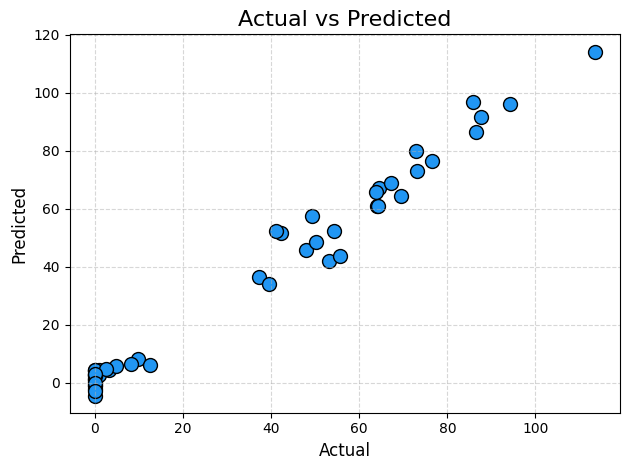

In [24]:
# Write your code here

plt.scatter(y_test, y_pred, color='#2196F3', edgecolor='k', s=100)
plt.title('Actual vs Predicted', fontsize=16)
plt.xlabel('Actual', fontsize=12)
plt.ylabel('Predicted', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Step 11 — Predict on New Patient Data

> Now we use the trained model to predict outcomes for **two new patients**.
> The new data must be scaled using the **same scaler fitted on training data**.


In [18]:
# Write your code here
new_patients = pd.DataFrame({
    'Age'               : [45,  72 ],
    'BMI'               : [24.5, 31.2],
    'Blood_Pressure'    : [120, 145 ],
    'Therapy_Hours'     : [12,   5  ],
    'Medication_Dosage' : [50,  80  ],
    'Preexisting_Score' : [2,    7  ]
})

# Fill any missing (none here, but good practice) then scale
new_patients_filled = new_patients.fillna(train_means)

preds = model.predict(new_patients_filled)

new_patients['Predicted_Recovery_Days']      = preds[:, 0].round(1)
new_patients['Predicted_Pain_Reduction']     = preds[:, 1].round(1)

print('🏥 Predicted Patient Outcomes:')
print(new_patients.to_string(index=False))

🏥 Predicted Patient Outcomes:
 Age  BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  Preexisting_Score  Predicted_Recovery_Days  Predicted_Pain_Reduction
  45 24.5             120             12                 50                  2                     52.0                       4.2
  72 31.2             145              5                 80                  7                    105.0                      -3.3
